# Global Wheat Head Augmentation Analysis

This notebook inspects the 3-seed copy-paste augmentation result in `results/13_multiseed_score_vs_noscore_copy_paste_exp_global_wheat_head` and compares score-guided vs non-score-guided augmentation.

It covers three questions:
- AP comparison across seeds and conditions
- How many new objects were created
- Which source domains the new objects came from, and how they are distributed in the final augmented dataset

The notebook reads the experiment summary JSON and the augmentation provenance JSON files under `train/metadata`.

In [10]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)

PROJECT_ROOT = Path('/home/khanh/Projects/DifficultyAgri')
EXPERIMENT_ROOT = PROJECT_ROOT / 'results' / '13_multiseed_score_vs_noscore_copy_paste_exp_global_wheat_head'
SUMMARY_PATH = EXPERIMENT_ROOT / 'summary_score_vs_without_score_3seeds.json'
RAW_ROOT = PROJECT_ROOT / 'datasets' / 'global_wheat_head' / 'raw'
IMAGE_EXTENSIONS = {'.png', '.jpg', '.jpeg', '.bmp', '.webp'}

def build_domain_map(raw_root: Path) -> dict[str, str]:
    domain_map: dict[str, str] = {}
    for domain_dir in sorted([p for p in raw_root.iterdir() if p.is_dir()]):
        if domain_dir.name == 'labels_extracted':
            continue
        for image_path in domain_dir.rglob('*'): 
            if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
                domain_map[image_path.stem] = domain_dir.name
    return domain_map

def load_summary(summary_path: Path) -> dict:
    with summary_path.open('r', encoding='utf-8') as f:
        return json.load(f)

def load_augmented_provenance(experiment_root: Path, condition: str, seed: int, domain_map: dict[str, str]) -> pd.DataFrame:
    metadata_dir = experiment_root / f'seed_{seed}' / 'Step_4_Copy_Paste_Augmentation' / condition / 'augmented_dataset' / 'train' / 'metadata'
    rows = []
    if not metadata_dir.exists():
        return pd.DataFrame(rows)

    for metadata_path in sorted(metadata_dir.glob('aug_*.json')):
        with metadata_path.open('r', encoding='utf-8') as f:
            payload = json.load(f)

        background_name = payload.get('background_image_name', '')
        background_domain = domain_map.get(Path(background_name).stem, 'unknown')
        selected_objects = payload.get('selected_objects', [])
        pasted_count = int(payload.get('pasted_object_count', len(selected_objects)))

        for obj in selected_objects:
            source_name = obj.get('source_image_name', '')
            source_domain = domain_map.get(Path(source_name).stem, 'unknown')
            rows.append({
                'seed': int(seed),
                'condition': condition,
                'augmented_image': metadata_path.stem,
                'background_image_name': background_name,
                'background_domain': background_domain,
                'source_image_name': source_name,
                'source_domain': source_domain,
                'source_object_index': int(obj.get('source_object_index', -1)),
                'class_id': int(obj.get('class_id', -1)),
                'score': float(obj.get('score', 0.0)),
                'pasted_count': pasted_count,
                'num_selected_objects': len(selected_objects),
                'cross_domain': source_domain != background_domain,
            })

    return pd.DataFrame(rows)

summary = load_summary(SUMMARY_PATH)
domain_map = build_domain_map(RAW_ROOT)
seeds = summary['seeds']
conditions = list(summary['conditions'].keys())
metrics = ['COCO_AP', 'COCO_AP50', 'COCO_AP75', 'AP_small', 'AP_medium', 'AP_large']

print(f'Loaded {len(domain_map)} image-to-domain mappings.')
print(f'Seeds: {seeds}')
print(f'Conditions: {conditions}')

provenance_frames = []
for condition in conditions:
    for seed in seeds:
        provenance_frames.append(load_augmented_provenance(EXPERIMENT_ROOT, condition, seed, domain_map))

provenance_df = pd.concat(provenance_frames, ignore_index=True) if provenance_frames else pd.DataFrame()
display(provenance_df.head())

Loaded 4698 image-to-domain mappings.
Seeds: [123, 456, 789]
Conditions: ['with_score', 'without_score']


,seed,condition,augmented_image,background_image_name,background_domain,source_image_name,source_domain,source_object_index,class_id,score,pasted_count,num_selected_objects,cross_domain
0,123,with_score,aug_0001_0f2de787-b7e2-4b8a-8292-f16e96e53ded,0f2de787-b7e2-4b8a-8292-f16e96e53ded.png,arvalis_1,c9dbb928-0584-4c3c-8e6a-657f207029dc.png,arvalis_1,7,0,0.223435,2,2,False
1,123,with_score,aug_0001_0f2de787-b7e2-4b8a-8292-f16e96e53ded,0f2de787-b7e2-4b8a-8292-f16e96e53ded.png,arvalis_1,44bdcfb4-140d-47ec-a8cd-3bdb488948d2.png,arvalis_1,25,0,0.329336,2,2,False
2,123,with_score,aug_0002_e947cc88-e023-4c43-b4ad-8c9fee5546c9,e947cc88-e023-4c43-b4ad-8c9fee5546c9.png,arvalis_1,e3f10100-ee9c-46ac-8d63-ee78d10edda0.png,arvalis_1,11,0,0.547058,2,2,False
3,123,with_score,aug_0002_e947cc88-e023-4c43-b4ad-8c9fee5546c9,e947cc88-e023-4c43-b4ad-8c9fee5546c9.png,arvalis_1,6178bc2b-0518-462c-a01d-1df541ddbf75.png,arvalis_1,38,0,0.358577,2,2,False
4,123,with_score,aug_0003_f5753c7a-3ad1-4086-924e-587be91f79c8,f5753c7a-3ad1-4086-924e-587be91f79c8.png,arvalis_2,67276712-3902-4ea5-baf4-e4c10b5cc609.png,arvalis_1,16,0,0.434065,2,2,True


## AP comparison

This section summarizes the model AP on the original test split for the baseline, the score-guided augmentation run, and the non-score-guided augmentation run.

The delta values are `augmented - baseline` per seed, then averaged across the 3 seeds.

,seed,condition,aug_COCO_AP,aug_COCO_AP50,aug_COCO_AP75,aug_AP_small,aug_AP_medium,aug_AP_large,delta_COCO_AP,delta_COCO_AP50,delta_COCO_AP75,delta_AP_small,delta_AP_medium,delta_AP_large,baseline_COCO_AP,baseline_COCO_AP50,baseline_COCO_AP75,baseline_AP_small,baseline_AP_medium,baseline_AP_large
0,123,with_score,0.479746,0.899397,0.447231,0.099016,0.475576,0.517353,-0.029220,-0.026505,-0.042910,-0.035558,-0.026677,-0.035157,0.508966,0.925902,0.490140,0.134575,0.502253,0.552510
1,456,with_score,0.485454,0.907846,0.459232,0.092241,0.476802,0.541670,-0.020935,-0.015373,-0.031864,-0.033066,-0.025771,-0.001373,0.506389,0.923219,0.491095,0.125307,0.502573,0.543043
2,789,with_score,0.485819,0.906366,0.458345,0.104226,0.479293,0.533392,-0.019808,-0.011301,-0.032554,-0.045265,-0.019894,-0.020706,0.505627,0.917667,0.490899,0.149491,0.499187,0.554098
3,123,without_score,0.488356,0.904211,0.462543,0.127005,0.482746,0.529267,-0.020610,-0.021691,-0.027597,-0.007570,-0.019507,-0.023243,0.508966,0.925902,0.490140,0.134575,0.502253,0.552510
4,456,without_score,0.485974,0.907352,0.456061,0.091538,0.478970,0.532607,-0.020415,-0.015867,-0.035034,-0.033768,-0.023603,-0.010436,0.506389,0.923219,0.491095,0.125307,0.502573,0.543043
5,789,without_score,0.482775,0.902721,0.448090,0.135941,0.477061,0.524368,-0.022852,-0.014946,-0.042809,-0.013550,-0.022126,-0.029730,0.505627,0.917667,0.490899,0.149491,0.499187,0.554098


,metric,baseline_mean,baseline_std,with_score_mean,with_score_std,with_score_delta_mean,with_score_delta_std,without_score_mean,without_score_std,without_score_delta_mean,without_score_delta_std
0,COCO_AP,0.506994,0.001429,0.483673,0.002781,-0.023321,0.004196,0.485701,0.002287,-0.021292,0.001106
1,COCO_AP50,0.922263,0.003429,0.904536,0.003684,-0.017726,0.006426,0.904761,0.001930,-0.017501,0.002986
2,COCO_AP75,0.490711,0.000412,0.454936,0.005460,-0.035776,0.005052,0.455565,0.005911,-0.035147,0.006211
3,AP_small,0.136457,0.009962,0.098494,0.004907,-0.037963,0.005262,0.118161,0.019176,-0.018296,0.011210
4,AP_medium,0.501338,0.001526,0.477224,0.001547,-0.024114,0.003007,0.479592,0.002362,-0.021746,0.001693
5,AP_large,0.549884,0.004880,0.530805,0.010094,-0.019079,0.013840,0.528747,0.003384,-0.021136,0.008017


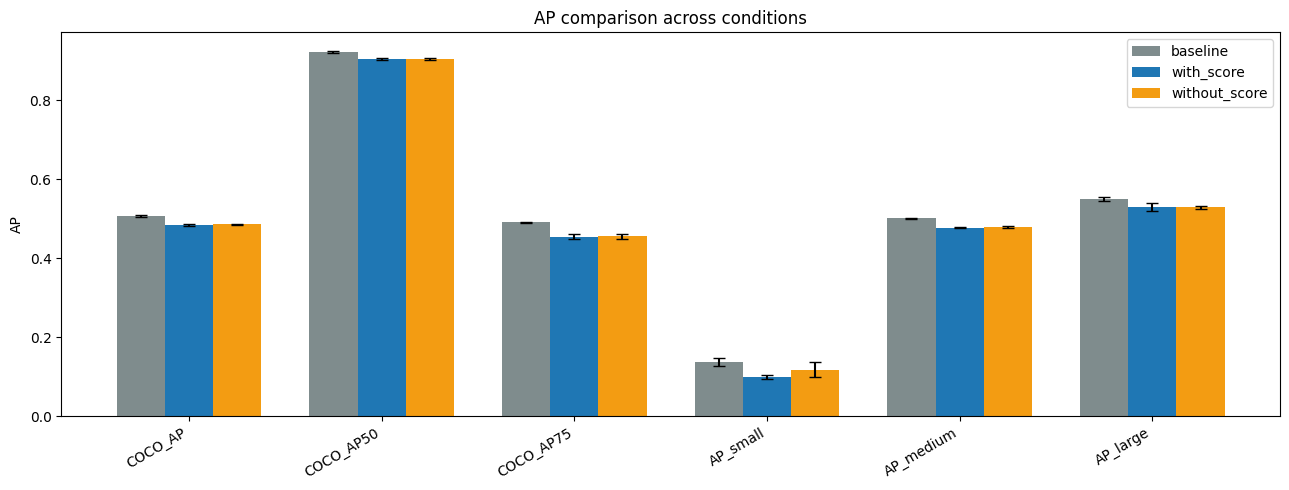

condition,with_score,without_score
seed,,
123,-0.029220,-0.020610
456,-0.020935,-0.020415
789,-0.019808,-0.022852


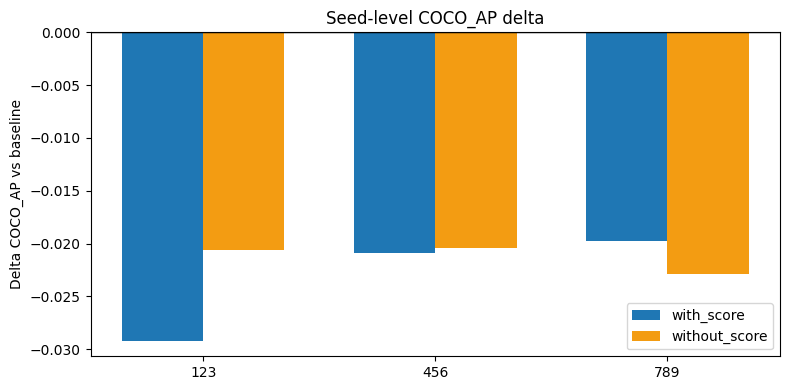

,comparison,COCO_AP_mean_gap,with_score_delta_mean,without_score_delta_mean,recommended_condition
0,with_score - without_score,-0.002028,-0.023321,-0.021292,without_score


In [11]:
ap_rows = []
for condition in conditions:
    for run in summary['conditions'][condition]:
        row = {'seed': run['seed'], 'condition': condition}
        row.update({f'aug_{metric}': run['augmented_eval_on_original_test'][metric] for metric in metrics})
        row.update({f'delta_{metric}': run['delta_aug_minus_baseline'][metric] for metric in metrics})
        row.update({f'baseline_{metric}': run['baseline_eval_on_original_test'][metric] for metric in metrics})
        ap_rows.append(row)

ap_df = pd.DataFrame(ap_rows).sort_values(['condition', 'seed']).reset_index(drop=True)
display(ap_df)

ap_summary_rows = []
for metric in metrics:
    ap_summary_rows.append({
        'metric': metric,
        'baseline_mean': summary['aggregate']['baseline_eval_on_original_test'][metric]['mean'],
        'baseline_std': summary['aggregate']['baseline_eval_on_original_test'][metric]['std'],
        'with_score_mean': summary['aggregate']['with_score']['augmented_eval_on_original_test'][metric]['mean'],
        'with_score_std': summary['aggregate']['with_score']['augmented_eval_on_original_test'][metric]['std'],
        'with_score_delta_mean': summary['aggregate']['with_score']['delta_aug_minus_baseline'][metric]['mean'],
        'with_score_delta_std': summary['aggregate']['with_score']['delta_aug_minus_baseline'][metric]['std'],
        'without_score_mean': summary['aggregate']['without_score']['augmented_eval_on_original_test'][metric]['mean'],
        'without_score_std': summary['aggregate']['without_score']['augmented_eval_on_original_test'][metric]['std'],
        'without_score_delta_mean': summary['aggregate']['without_score']['delta_aug_minus_baseline'][metric]['mean'],
        'without_score_delta_std': summary['aggregate']['without_score']['delta_aug_minus_baseline'][metric]['std'],
    })

ap_summary_df = pd.DataFrame(ap_summary_rows)
display(ap_summary_df)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(metrics))
width = 0.25
baseline_means = [summary['aggregate']['baseline_eval_on_original_test'][metric]['mean'] for metric in metrics]
baseline_stds = [summary['aggregate']['baseline_eval_on_original_test'][metric]['std'] for metric in metrics]
with_score_means = [summary['aggregate']['with_score']['augmented_eval_on_original_test'][metric]['mean'] for metric in metrics]
with_score_stds = [summary['aggregate']['with_score']['augmented_eval_on_original_test'][metric]['std'] for metric in metrics]
without_score_means = [summary['aggregate']['without_score']['augmented_eval_on_original_test'][metric]['mean'] for metric in metrics]
without_score_stds = [summary['aggregate']['without_score']['augmented_eval_on_original_test'][metric]['std'] for metric in metrics]
ax.bar(x - width, baseline_means, width=width, yerr=baseline_stds, capsize=4, label='baseline', color='#7f8c8d')
ax.bar(x, with_score_means, width=width, yerr=with_score_stds, capsize=4, label='with_score', color='#1f77b4')
ax.bar(x + width, without_score_means, width=width, yerr=without_score_stds, capsize=4, label='without_score', color='#f39c12')
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=30, ha='right')
ax.set_ylabel('AP')
ax.set_title('AP comparison across conditions')
ax.legend()
plt.tight_layout()
plt.show()

seed_delta_df = ap_df[['seed', 'condition', 'delta_COCO_AP']].pivot(index='seed', columns='condition', values='delta_COCO_AP').reindex(seeds)
display(seed_delta_df)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(seed_delta_df.index))
width = 0.35
ax.bar(x - width / 2, seed_delta_df['with_score'], width=width, label='with_score', color='#1f77b4')
ax.bar(x + width / 2, seed_delta_df['without_score'], width=width, label='without_score', color='#f39c12')
ax.axhline(0.0, color='black', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(seed_delta_df.index.astype(str))
ax.set_ylabel('Delta COCO_AP vs baseline')
ax.set_title('Seed-level COCO_AP delta')
ax.legend()
plt.tight_layout()
plt.show()

display(pd.DataFrame([{
    'comparison': 'with_score - without_score',
    'COCO_AP_mean_gap': summary['comparison']['mean_delta_advantage_with_score'],
    'with_score_delta_mean': summary['comparison']['with_score_mean_delta_coco_ap'],
    'without_score_delta_mean': summary['comparison']['without_score_mean_delta_coco_ap'],
    'recommended_condition': summary['comparison']['recommendation'],
}]))

## New object count and domain analysis

This section counts how many pasted objects were created in each condition, then breaks those pasted objects down by source domain.

The `source_domain` column tells you which wheat-head domain each pasted object came from.

,condition,seed,augmented_image,background_image_name,background_domain,new_objects,cross_domain_objects,cross_domain_rate
0,with_score,123,aug_0001_0f2de787-b7e2-4b8a-8292-f16e96e53ded,0f2de787-b7e2-4b8a-8292-f16e96e53ded.png,arvalis_1,2,0,0.0
1,with_score,123,aug_0002_e947cc88-e023-4c43-b4ad-8c9fee5546c9,e947cc88-e023-4c43-b4ad-8c9fee5546c9.png,arvalis_1,2,0,0.0
2,with_score,123,aug_0003_f5753c7a-3ad1-4086-924e-587be91f79c8,f5753c7a-3ad1-4086-924e-587be91f79c8.png,arvalis_2,2,2,1.0
3,with_score,123,aug_0004_e624b107-5bff-4a04-964c-2e1a165d9081,e624b107-5bff-4a04-964c-2e1a165d9081.png,arvalis_1,5,3,0.6
4,with_score,123,aug_0005_742389d7-6509-44b4-97b2-6bc89acf206b,742389d7-6509-44b4-97b2-6bc89acf206b.png,ethz_1,2,1,0.5


,condition,augmented_images,new_objects,avg_new_objects_per_augmented_image,cross_domain_rate_mean,cross_domain_rate_std
0,with_score,2430,8534,3.511934,0.765727,0.272712
1,without_score,2430,8544,3.516049,0.786392,0.252051


,condition,source_domain,new_object_count,total_new_objects,fraction
0,with_score,arvalis_1,3398,8534,0.398172
3,with_score,ethz_1,2353,8534,0.275721
2,with_score,arvalis_3,997,8534,0.116827
5,with_score,rres_1,831,8534,0.097375
6,with_score,usask_1,402,8534,0.047106
1,with_score,arvalis_2,379,8534,0.044411
4,with_score,inrae_1,174,8534,0.020389
10,without_score,ethz_1,3016,8544,0.352996
7,without_score,arvalis_1,2551,8544,0.298572
12,without_score,rres_1,1175,8544,0.137523


,condition,source_domain,new_object_count,total_new_objects,fraction
0,with_score,arvalis_1,3398,8534,0.398172
10,without_score,ethz_1,3016,8544,0.352996


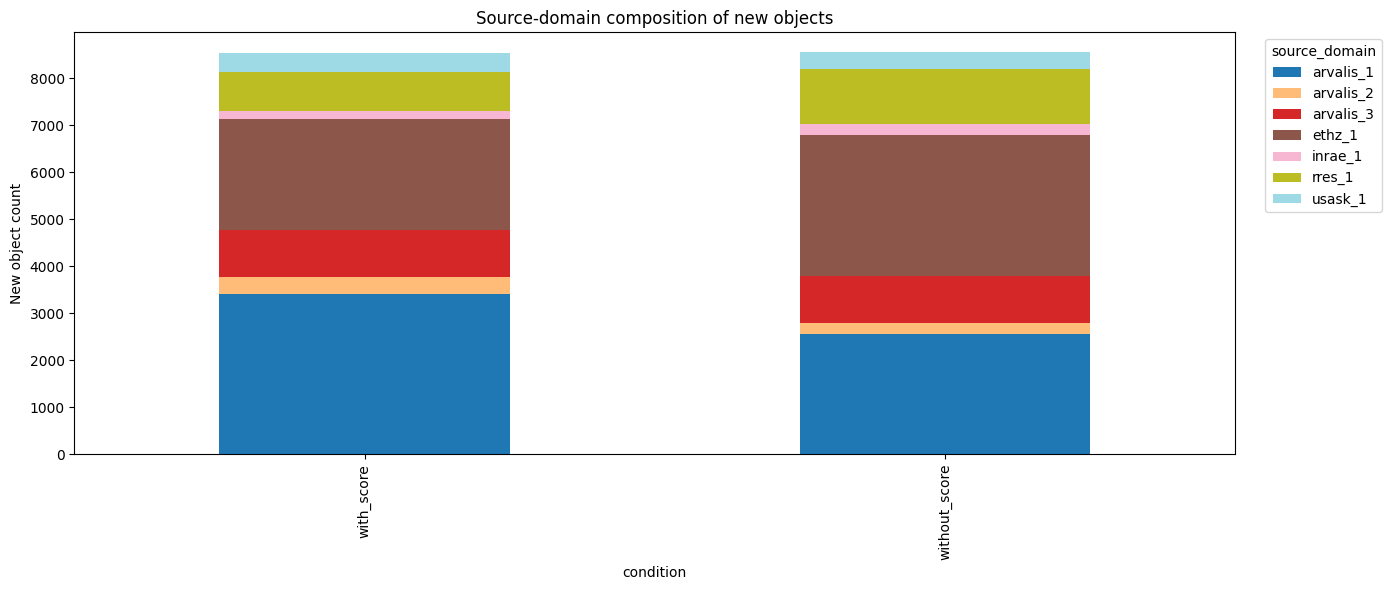

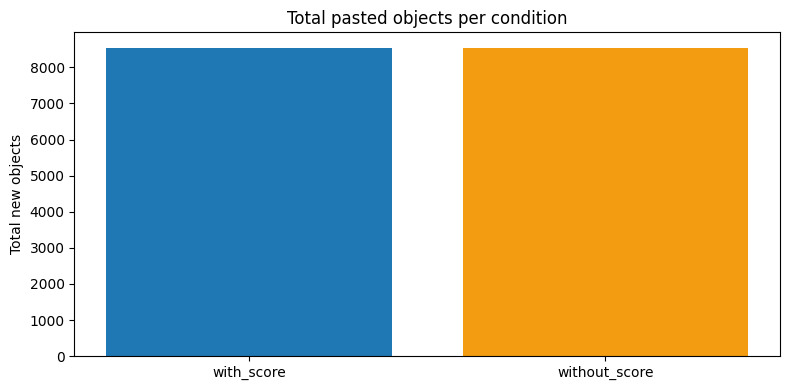

/tmp/ipykernel_1338200/3269277617.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(rate_data, labels=conditions, showmeans=True)


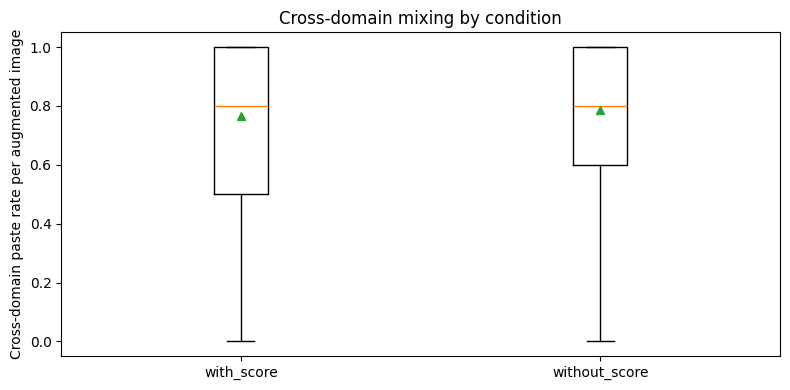

,condition,augmented_images,new_objects,avg_new_objects_per_augmented_image,cross_domain_rate_mean,cross_domain_rate_std
0,with_score,2430,8534,3.511934,0.765727,0.272712
1,without_score,2430,8544,3.516049,0.786392,0.252051


In [12]:
if provenance_df.empty:
    raise RuntimeError('No augmentation provenance found. Check the result directory layout.')

per_image_df = provenance_df.groupby([
    'condition',
    'seed',
    'augmented_image',
    'background_image_name',
    'background_domain',
], as_index=False).agg(
    new_objects=('source_image_name', 'size'),
    cross_domain_objects=('cross_domain', 'sum'),
)
per_image_df['cross_domain_rate'] = per_image_df['cross_domain_objects'] / per_image_df['new_objects']
display(per_image_df.head())

objects_summary_rows = []
for condition in conditions:
    condition_images = per_image_df[per_image_df['condition'] == condition]
    condition_objects = provenance_df[provenance_df['condition'] == condition]
    objects_summary_rows.append({
        'condition': condition,
        'augmented_images': int(condition_images.shape[0]),
        'new_objects': int(condition_objects.shape[0]),
        'avg_new_objects_per_augmented_image': float(condition_objects.shape[0] / max(1, condition_images.shape[0])),
        'cross_domain_rate_mean': float(condition_images['cross_domain_rate'].mean()),
        'cross_domain_rate_std': float(condition_images['cross_domain_rate'].std(ddof=0)),
    })

objects_summary_df = pd.DataFrame(objects_summary_rows)
display(objects_summary_df)

domain_counts_df = provenance_df.groupby(['condition', 'source_domain'], as_index=False).size().rename(columns={'size': 'new_object_count'})
total_by_condition = domain_counts_df.groupby('condition', as_index=False)['new_object_count'].sum().rename(columns={'new_object_count': 'total_new_objects'})
domain_counts_df = domain_counts_df.merge(total_by_condition, on='condition', how='left')
domain_counts_df['fraction'] = domain_counts_df['new_object_count'] / domain_counts_df['total_new_objects']
display(domain_counts_df.sort_values(['condition', 'new_object_count'], ascending=[True, False]))

top_domain_df = domain_counts_df.sort_values(['condition', 'new_object_count'], ascending=[True, False]).groupby('condition').head(1)
display(top_domain_df)

condition_domain_pivot = domain_counts_df.pivot(index='condition', columns='source_domain', values='new_object_count').fillna(0)
condition_domain_pivot = condition_domain_pivot.reindex(conditions)
fig, ax = plt.subplots(figsize=(14, 6))
condition_domain_pivot.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
ax.set_ylabel('New object count')
ax.set_title('Source-domain composition of new objects')
ax.legend(title='source_domain', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(objects_summary_df))
ax.bar(x, objects_summary_df['new_objects'], color=['#1f77b4', '#f39c12'])
ax.set_xticks(x)
ax.set_xticklabels(objects_summary_df['condition'])
ax.set_ylabel('Total new objects')
ax.set_title('Total pasted objects per condition')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
rate_data = [per_image_df.loc[per_image_df['condition'] == condition, 'cross_domain_rate'].to_numpy() for condition in conditions]
ax.boxplot(rate_data, labels=conditions, showmeans=True)
ax.set_ylabel('Cross-domain paste rate per augmented image')
ax.set_title('Cross-domain mixing by condition')
plt.tight_layout()
plt.show()

display(pd.DataFrame([{
    'condition': row['condition'],
    'augmented_images': row['augmented_images'],
    'new_objects': row['new_objects'],
    'avg_new_objects_per_augmented_image': row['avg_new_objects_per_augmented_image'],
    'cross_domain_rate_mean': row['cross_domain_rate_mean'],
    'cross_domain_rate_std': row['cross_domain_rate_std'],
} for _, row in objects_summary_df.iterrows()]))

## Interpretation

Read the AP plots to compare score-guided vs non-score-guided augmentation on the test set.

Read the object-domain tables to see where the pasted objects came from and whether one domain dominates the final augmented dataset.

If you want a lighter version later, the same notebook can be narrowed to just COCO_AP, total new objects, and the domain-count bar chart.

## Experiment 05 output analysis

This section analyzes results from `results/05_copy_paste_exp` directly.

It reports:
- baseline vs augmented AP from Step 5 evaluation JSON files
- number of new pasted objects
- source-domain distribution of pasted objects
- cross-domain paste rate

,metric,baseline,augmented,delta_aug_minus_baseline
0,COCO_AP,0.508966,0.478298,-0.030668
1,COCO_AP50,0.925902,0.898879,-0.027023
2,COCO_AP75,0.490140,0.452936,-0.037204
3,AP_small,0.134575,0.100756,-0.033818
4,AP_medium,0.502253,0.476426,-0.025828
5,AP_large,0.552510,0.508954,-0.043556


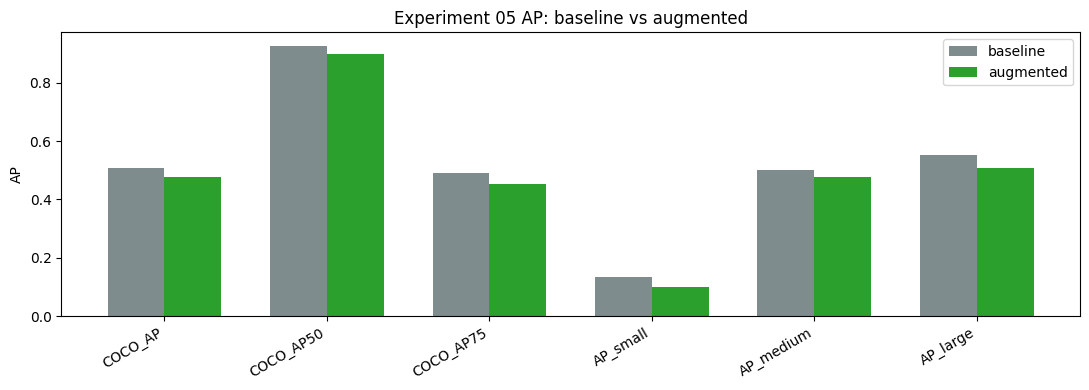

Experiment 05 metadata rows (new pasted objects): 3,975


,augmented_image,background_image_name,background_domain,new_objects,cross_domain_objects,cross_domain_rate
0,aug_0001_16824eb4-a603-43db-9007-a621e8c5eb4e,16824eb4-a603-43db-9007-a621e8c5eb4e.png,ethz_1,4,0,0.0
1,aug_0002_e90b1118-4fdf-4b97-8aba-962e56483c68,e90b1118-4fdf-4b97-8aba-962e56483c68.png,arvalis_1,8,0,0.0
2,aug_0003_dd7ecb4a-cc13-4343-b1e1-cd1746dd1e3a,dd7ecb4a-cc13-4343-b1e1-cd1746dd1e3a.png,arvalis_3,4,0,0.0
3,aug_0004_98e2680b-744c-4814-bec9-6bea40f205d2,98e2680b-744c-4814-bec9-6bea40f205d2.png,ethz_1,5,0,0.0
4,aug_0005_c670eebc-c948-40eb-84a5-25d146095b48,c670eebc-c948-40eb-84a5-25d146095b48.png,arvalis_1,2,0,0.0


,augmented_images,new_objects,avg_new_objects_per_augmented_image,cross_domain_rate_mean,cross_domain_rate_std
0,810,3975,4.907407,0.0,0.0


,source_domain,new_object_count,fraction
0,arvalis_1,1227,0.308679
1,ethz_1,930,0.233962
2,arvalis_3,624,0.156981
3,rres_1,494,0.124277
4,arvalis_2,277,0.069686
5,inrae_1,232,0.058365
6,usask_1,191,0.048050


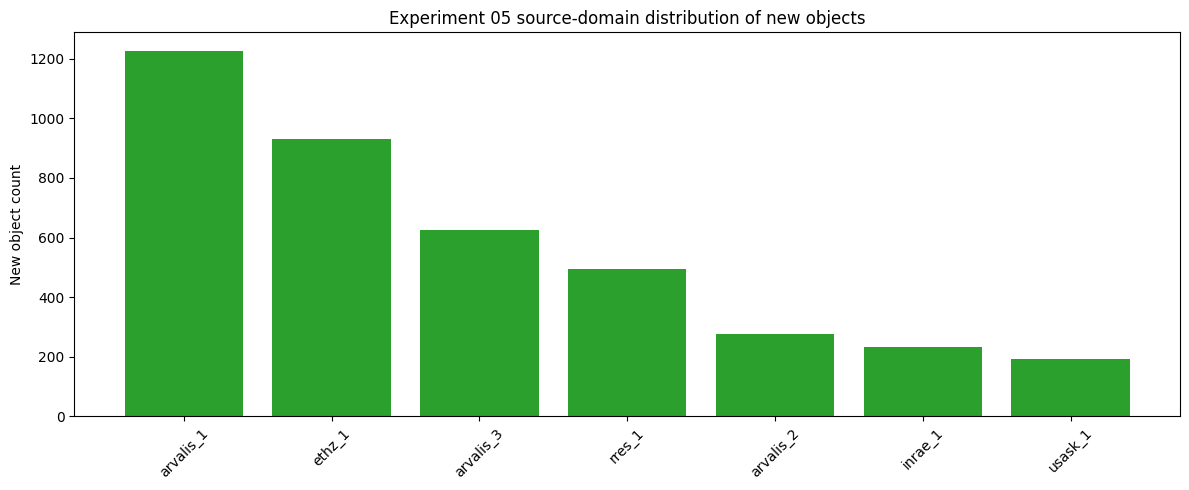

/tmp/ipykernel_1338200/2579326528.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([exp05_per_image['cross_domain_rate'].to_numpy()], labels=['exp05'], showmeans=True)


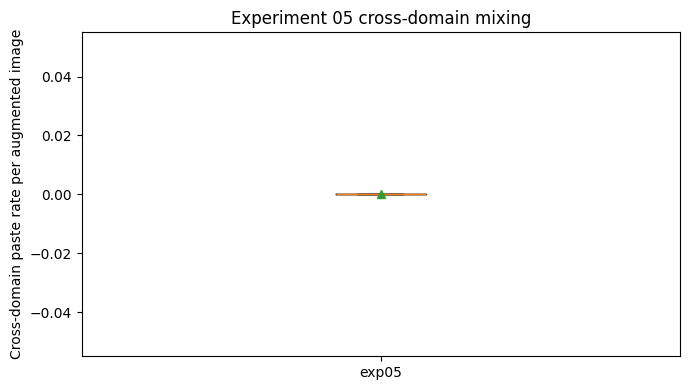

,comparison,experiment_05_delta,experiment_13_without_score_mean_delta,difference_exp05_minus_exp13_without_score_mean
0,COCO_AP delta (augmented - baseline),-0.030668,-0.021292,-0.009375


In [13]:
EXP05_ROOT = PROJECT_ROOT / 'results' / '05_copy_paste_exp'
EXP05_METADATA_DIR = EXP05_ROOT / 'Step_4_Copy_Paste_Augmentation' / 'augmented_dataset' / 'train' / 'metadata'
EXP05_BASELINE_EVAL = EXP05_ROOT / 'Step_5_Train_and_Evaluate_Model_on_Augmented_Dataset' / 'evaluation_report_initial_dataset.json'
EXP05_AUG_EVAL = EXP05_ROOT / 'Step_5_Train_and_Evaluate_Model_on_Augmented_Dataset' / 'evaluation_report_new_dataset.json'

def load_exp05_provenance(metadata_dir: Path, domain_map: dict[str, str]) -> pd.DataFrame:
    rows = []
    if not metadata_dir.exists():
        return pd.DataFrame(rows)

    for metadata_path in sorted(metadata_dir.glob('aug_*.json')):
        with metadata_path.open('r', encoding='utf-8') as f:
            payload = json.load(f)

        background_name = payload.get('background_image_name', '')
        background_domain = domain_map.get(Path(background_name).stem, 'unknown')
        selected_objects = payload.get('selected_objects', [])
        pasted_count = int(payload.get('pasted_object_count', len(selected_objects)))

        for obj in selected_objects:
            source_name = obj.get('source_image_name', '')
            source_domain = domain_map.get(Path(source_name).stem, 'unknown')
            rows.append({
                'augmented_image': metadata_path.stem,
                'background_image_name': background_name,
                'background_domain': background_domain,
                'source_image_name': source_name,
                'source_domain': source_domain,
                'source_object_index': int(obj.get('source_object_index', -1)),
                'class_id': int(obj.get('class_id', -1)),
                'score': float(obj.get('score', 0.0)),
                'pasted_count': pasted_count,
                'cross_domain': source_domain != background_domain,
            })

    return pd.DataFrame(rows)

def load_eval_json(path: Path) -> dict:
    if not path.exists():
        return {}
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)

exp05_base = load_eval_json(EXP05_BASELINE_EVAL)
exp05_aug = load_eval_json(EXP05_AUG_EVAL)
exp05_prov = load_exp05_provenance(EXP05_METADATA_DIR, domain_map)

if not exp05_base or not exp05_aug:
    print('Missing Step 5 evaluation files for experiment 05.')
else:
    exp05_ap_rows = []
    for metric in metrics:
        exp05_ap_rows.append({
            'metric': metric,
            'baseline': exp05_base.get(metric, np.nan),
            'augmented': exp05_aug.get(metric, np.nan),
            'delta_aug_minus_baseline': exp05_aug.get(metric, np.nan) - exp05_base.get(metric, np.nan),
        })
    exp05_ap_df = pd.DataFrame(exp05_ap_rows)
    display(exp05_ap_df)

    fig, ax = plt.subplots(figsize=(11, 4))
    x = np.arange(len(metrics))
    width = 0.35
    ax.bar(x - width / 2, exp05_ap_df['baseline'], width=width, label='baseline', color='#7f8c8d')
    ax.bar(x + width / 2, exp05_ap_df['augmented'], width=width, label='augmented', color='#2ca02c')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=30, ha='right')
    ax.set_ylabel('AP')
    ax.set_title('Experiment 05 AP: baseline vs augmented')
    ax.legend()
    plt.tight_layout()
    plt.show()

if exp05_prov.empty:
    print('No provenance metadata found for experiment 05.')
else:
    print(f'Experiment 05 metadata rows (new pasted objects): {len(exp05_prov):,}')

    exp05_per_image = exp05_prov.groupby(['augmented_image', 'background_image_name', 'background_domain'], as_index=False).agg(
        new_objects=('source_image_name', 'size'),
        cross_domain_objects=('cross_domain', 'sum'),
    )
    exp05_per_image['cross_domain_rate'] = exp05_per_image['cross_domain_objects'] / exp05_per_image['new_objects']
    display(exp05_per_image.head())

    exp05_summary = pd.DataFrame([{
        'augmented_images': int(exp05_per_image.shape[0]),
        'new_objects': int(exp05_prov.shape[0]),
        'avg_new_objects_per_augmented_image': float(exp05_prov.shape[0] / max(1, exp05_per_image.shape[0])),
        'cross_domain_rate_mean': float(exp05_per_image['cross_domain_rate'].mean()),
        'cross_domain_rate_std': float(exp05_per_image['cross_domain_rate'].std(ddof=0)),
    }])
    display(exp05_summary)

    exp05_domain_counts = exp05_prov.groupby('source_domain', as_index=False).size().rename(columns={'size': 'new_object_count'})
    exp05_domain_counts['fraction'] = exp05_domain_counts['new_object_count'] / exp05_domain_counts['new_object_count'].sum()
    exp05_domain_counts = exp05_domain_counts.sort_values('new_object_count', ascending=False).reset_index(drop=True)
    display(exp05_domain_counts)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(exp05_domain_counts['source_domain'], exp05_domain_counts['new_object_count'], color='#2ca02c')
    ax.set_ylabel('New object count')
    ax.set_title('Experiment 05 source-domain distribution of new objects')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.boxplot([exp05_per_image['cross_domain_rate'].to_numpy()], labels=['exp05'], showmeans=True)
    ax.set_ylabel('Cross-domain paste rate per augmented image')
    ax.set_title('Experiment 05 cross-domain mixing')
    plt.tight_layout()
    plt.show()

# Optional direct comparison vs experiment 13 aggregated no-score results
if not exp05_base or not exp05_aug:
    pass
else:
    exp05_delta_coco_ap = exp05_aug.get('COCO_AP', np.nan) - exp05_base.get('COCO_AP', np.nan)
    exp13_without_score_mean_delta = summary['aggregate']['without_score']['delta_aug_minus_baseline']['COCO_AP']['mean']
    display(pd.DataFrame([{
        'comparison': 'COCO_AP delta (augmented - baseline)',
        'experiment_05_delta': exp05_delta_coco_ap,
        'experiment_13_without_score_mean_delta': exp13_without_score_mean_delta,
        'difference_exp05_minus_exp13_without_score_mean': exp05_delta_coco_ap - exp13_without_score_mean_delta,
    }]))